In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()

df['target'] = cancer.target
print(df.head())
print(df.shape)


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [3]:
print(df.info())
print(df.describe())
print(df['target'].value_counts())
print(cancer.target_names)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(df['diagnosis'].value_counts())

diagnosis
benign       357
malignant    212
Name: count, dtype: int64


In [5]:
print(df[['target', 'diagnosis']].head())

   target  diagnosis
0       0  malignant
1       0  malignant
2       0  malignant
3       0  malignant
4       0  malignant


In [8]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
diagnosis                  0
dtype: int64


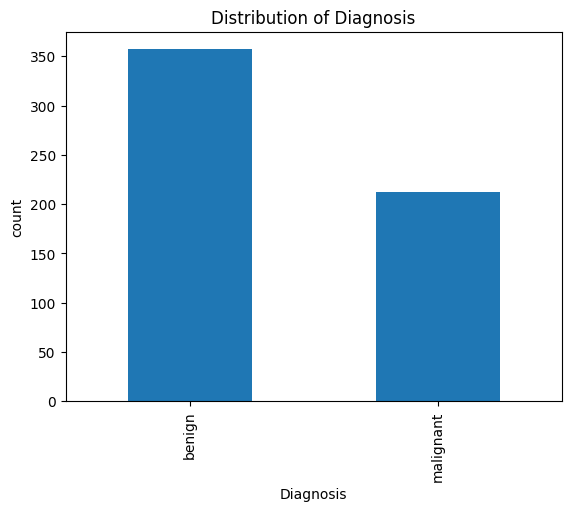

In [9]:
df['diagnosis'].value_counts().plot(kind='bar')
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('count')
plt.show()

In [10]:
df.iloc[ : 10].describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,...,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.0
mean,15.98,18.65,106.22,830.38,0.11,0.18,0.18,0.09,0.21,0.07,...,26.04,131.80,1252.20,0.16,0.51,0.53,0.21,0.39,0.12,0.0
std,3.69,4.11,23.68,377.61,0.02,0.07,0.07,0.03,0.03,0.01,...,6.83,31.59,570.80,0.03,0.29,0.26,0.04,0.12,0.04,0.0
min,11.42,10.38,77.58,386.10,0.08,0.08,0.09,0.06,0.18,0.06,...,16.67,97.65,567.70,0.12,0.19,0.24,0.16,0.24,0.08,0.0
25%,12.60,16.22,84.85,487.78,0.10,0.14,0.12,0.08,0.19,0.06,...,23.50,104.10,739.88,0.14,0.29,0.38,0.18,0.31,0.09,0.0
50%,15.85,20.18,104.90,789.45,0.12,0.17,0.19,0.09,0.21,0.07,...,26.02,131.40,1236.00,0.16,0.47,0.49,0.20,0.38,0.11,0.0
75%,19.33,21.14,128.20,1162.25,0.13,0.23,0.22,0.10,0.23,0.08,...,28.02,153.02,1683.25,0.18,0.63,0.65,0.24,0.44,0.12,0.0
max,20.57,24.04,135.10,1326.00,0.14,0.28,0.30,0.15,0.26,0.10,...,40.68,184.60,2019.00,0.21,1.06,1.10,0.27,0.66,0.21,0.0


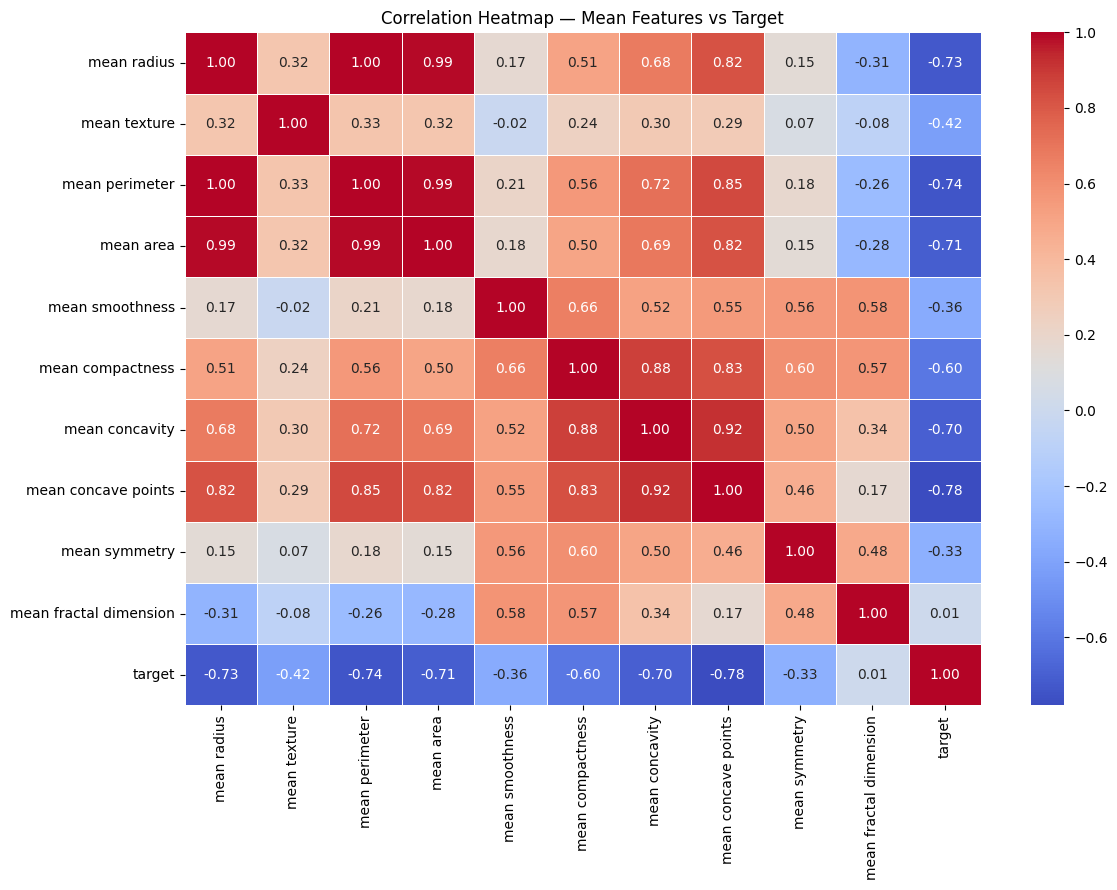

In [11]:
mean_features = [col for col in df.columns if 'mean' in col]
df_mean = df[mean_features + ['target']]

plt.figure(figsize=(12, 9))
corr = df_mean.corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — Mean Features vs Target')
plt.tight_layout()
plt.show()

C:\Users\Surya\AppData\Local\Temp\ipykernel_39456\2426024534.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([malignant, benign], labels=['malignant', 'benign'], patch_artist=True)
C:\Users\Surya\AppData\Local\Temp\ipykernel_39456\2426024534.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([malignant, benign], labels=['malignant', 'benign'], patch_artist=True)
C:\Users\Surya\AppData\Local\Temp\ipykernel_39456\2426024534.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([malignant, benign], labels=['malignant', 'benign'], patch_artist=True)
C:\Users\Surya\AppData

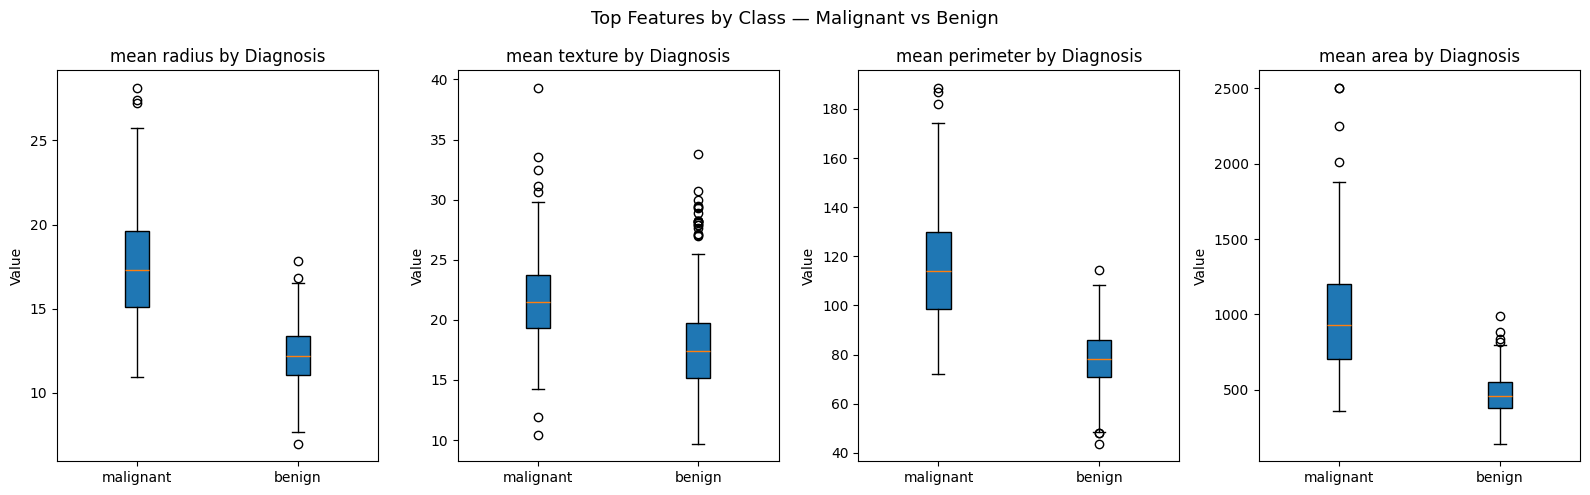

In [12]:
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(top_features):
    malignant = df[df['diagnosis'] == 'malignant'][col]
    benign = df[df['diagnosis'] == 'benign'][col]

    axes[i].boxplot([malignant, benign], labels=['malignant', 'benign'], patch_artist=True)
    axes[i].set_title(f'{col} by Diagnosis')
    axes[i].set_ylabel('Value')

plt.suptitle('Top Features by Class — Malignant vs Benign', fontsize=13)
plt.tight_layout()
plt.show()    

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target', 'diagnosis'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



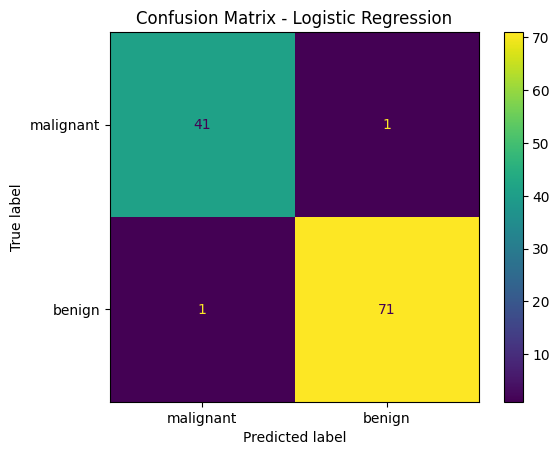

In [15]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=cancer.target_names))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    display_labels=cancer.target_names
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()